Going to try with matplot lib

I used chatgpt to help me generate some of this initial code

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

Read in dataframes, and then make a list of dataframes so I can run through them all

In [19]:
#election years
# 
df_2005 = pd.read_csv('DC-migration-2005.csv')
df_2009 = pd.read_csv('DC-migration-2009.csv')
df_2013 = pd.read_csv('DC-migration-2013.csv')
df_2017 = pd.read_csv('DC-migration-2017.csv')
df_2021 = pd.read_csv('DC-migration-2021.csv')


#non election years

df_2015 = pd.read_csv('DC-migration-2015.csv')
df_2016 = pd.read_csv('DC-migration-2016.csv')
df_2018 = pd.read_csv('DC-migration-2018.csv')
df_2019 = pd.read_csv('DC-migration-2019.csv')



#make a list

dfs = [df_2005, df_2009, df_2013, df_2015, df_2016, df_2017, df_2018, df_2019, df_2021]

Drop the initial columns that were carried over from the indexes and messing up this data.

In [20]:
df_2005 = df_2005.drop(columns=["Unnamed: 0"])
df_2009 = df_2009.drop(columns=["Unnamed: 0"])
df_2013 = df_2013.drop(columns=["Unnamed: 0"])
df_2015 = df_2015.drop(columns=["Unnamed: 0"])
df_2016 = df_2016.drop(columns=["Unnamed: 0"])
df_2017 = df_2017.drop(columns=["Unnamed: 0"])
df_2018 = df_2018.drop(columns=["Unnamed: 0"])
df_2019 = df_2019.drop(columns=["Unnamed: 0"])
df_2021 = df_2021.drop(columns=["Unnamed: 0"])


In [21]:
df_2005.tail()

,state,pop_migrated,MOE +/-,state_population,pop_migrated_upper,pop_migrated_lower,migrated_adjusted,migrated_adjusted_upper,migrated_adjusted_lower,moe_adjusted,winning_party,winner_percent_of_votes
43,Vermont,27,46,643077,73,-19,0.000042,0.000114,-0.000030,0.000072,DEMOCRAT,0.589375
44,Washington,443,354,7705281,797,89,0.000057,0.000103,0.000012,0.000046,DEMOCRAT,0.528211
45,West Virginia,389,376,1793716,765,13,0.000217,0.000426,0.000007,0.000210,REPUBLICAN,0.560707
46,Wisconsin,49,82,5893718,131,-33,0.000008,0.000022,-0.000006,0.000014,DEMOCRAT,0.496997
47,Wyoming,0,286,576851,286,-286,0.000000,0.000496,-0.000496,0.000496,REPUBLICAN,0.687396


Add in a state year column so in order to be able to loop through the dataframes


In [22]:
df_2005['year'] = 2005
df_2009['year'] = 2009
df_2013['year'] = 2013
df_2015['year'] = 2015
df_2016['year'] = 2016
df_2017['year'] = 2017
df_2018['year'] = 2018
df_2019['year'] = 2019
df_2021['year'] = 2021


Ok, multiplying by 100,000 to make the migrated_adjusted and moe_adjusted more readable 

In [23]:
for df in dfs:
    df['migrated_adjusted'] = df['migrated_adjusted'] * 100000
    df['moe_adjusted'] = df['moe_adjusted']* 100000

In the dataframes for non-election years, need to populate winner_percent_of_votes and winning_party columns with info from the most recent election year

In [24]:
df_2015['winning_party'] = df_2017['winning_party']
df_2016['winning_party'] = df_2017['winning_party']

df_2018['winning_party'] = df_2021['winning_party']
df_2019['winning_party'] = df_2021['winning_party']


df_2015['winner_percent_of_votes'] = df_2017['winner_percent_of_votes']
df_2016['winner_percent_of_votes'] = df_2017['winner_percent_of_votes']

df_2018['winner_percent_of_votes'] = df_2021['winner_percent_of_votes']
df_2019['winner_percent_of_votes'] = df_2021['winner_percent_of_votes']

#reset the list -- for some reason it needed me to run this otherwise it has like two different versions of these dfs saved
dfs = [df_2005, df_2009, df_2013, df_2015, df_2016, df_2017, df_2018, df_2019, df_2021]

df_2015.head()

,state,pop_migrated,MOE +/-,state_population,migrated_adjusted,moe_adjusted,year,winning_party,winner_percent_of_votes
0,Alabama,359,302,5024279,0.000071,0.000060,2015,REPUBLICAN,0.620831
1,Alaska,235,257,733391,0.000320,0.000350,2015,REPUBLICAN,0.512815
2,Arizona,367,293,7151502,0.000051,0.000041,2015,REPUBLICAN,0.486716
3,Arkansas,203,200,3011524,0.000067,0.000066,2015,REPUBLICAN,0.605741
4,California,4119,1258,39538223,0.000104,0.000032,2015,DEMOCRAT,0.617264


Make sure all the values I need are numeric.

In [25]:
for df in dfs:

    df["migrated_adjusted"] = pd.to_numeric(df["migrated_adjusted"])
    df["moe_adjusted"] = pd.to_numeric(df["moe_adjusted"])
    df["winner_percent_of_votes"] = pd.to_numeric(df["winner_percent_of_votes"])

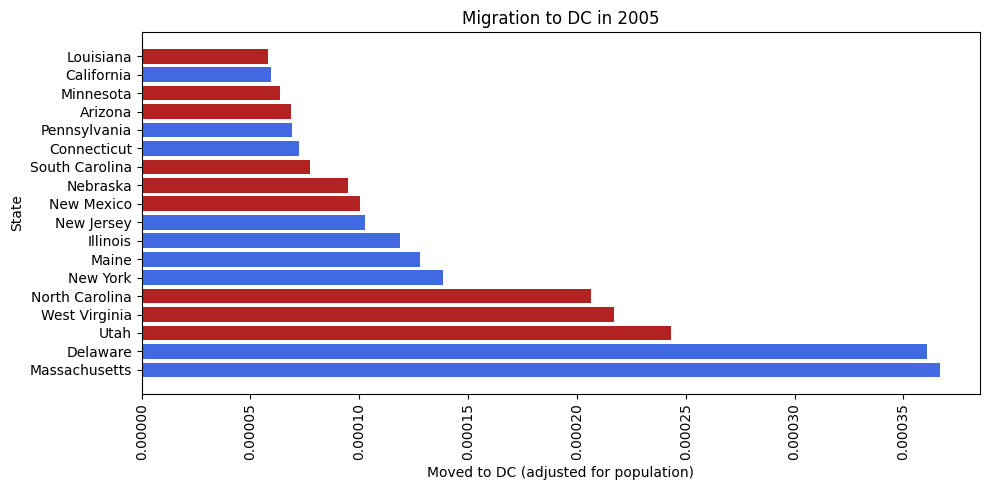

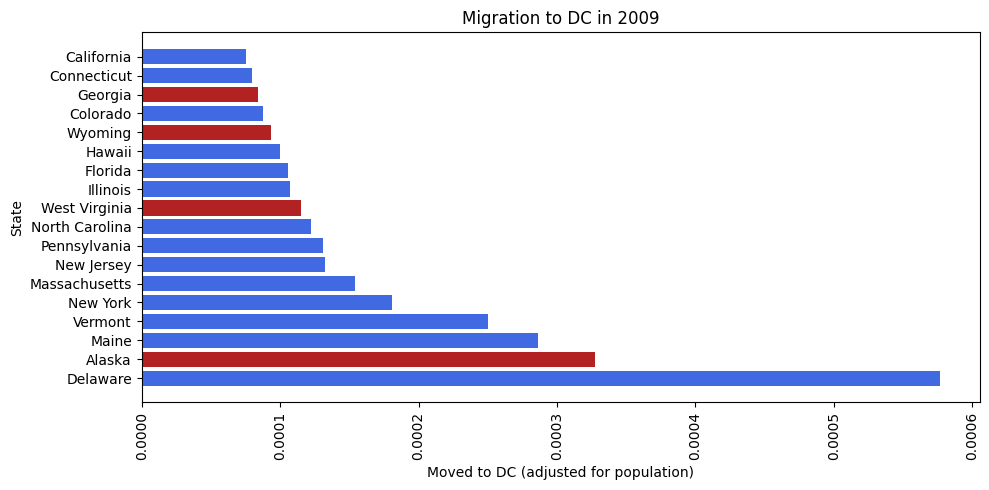

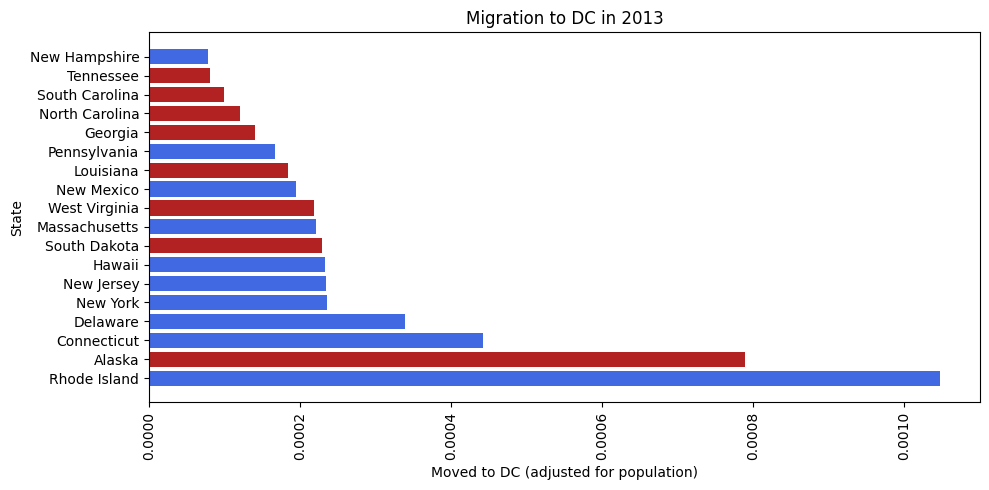

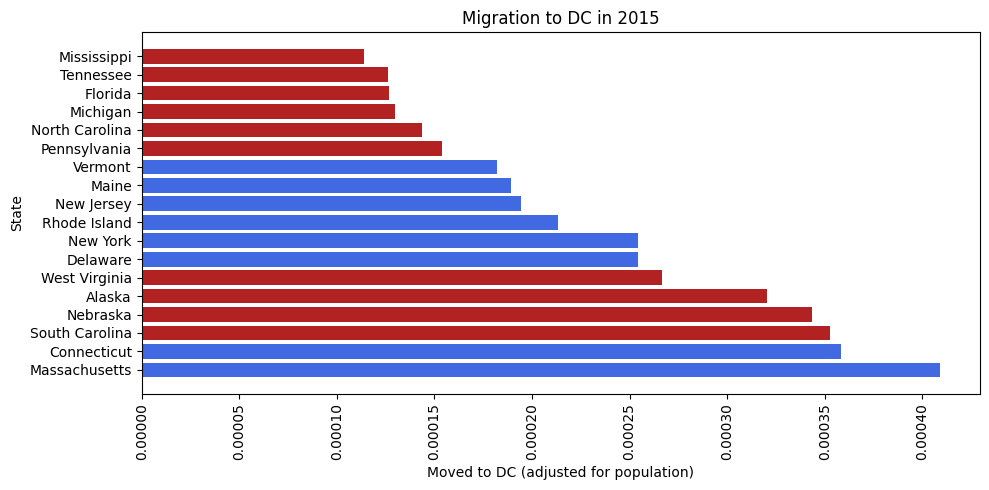

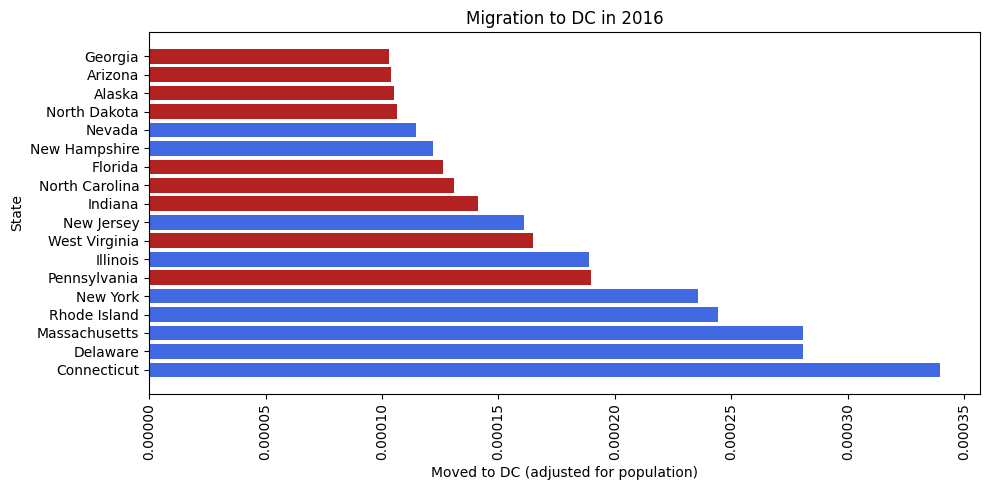

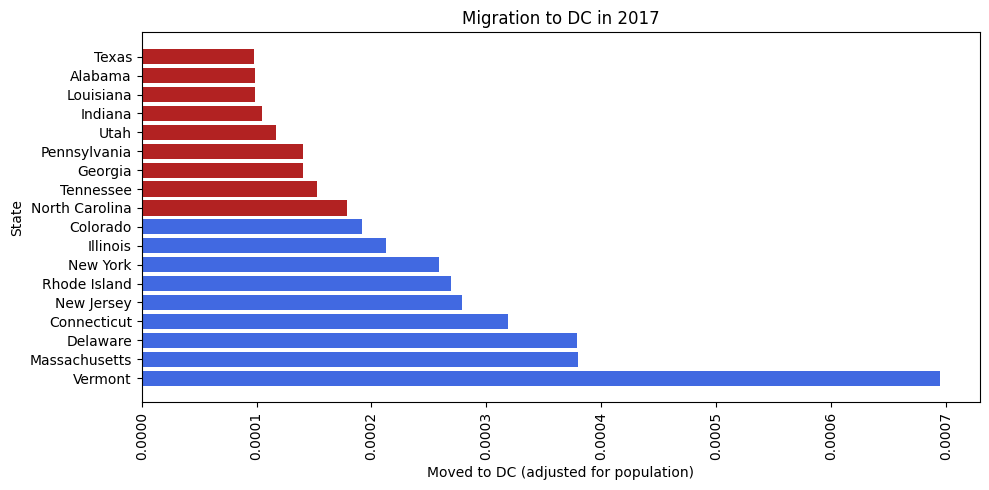

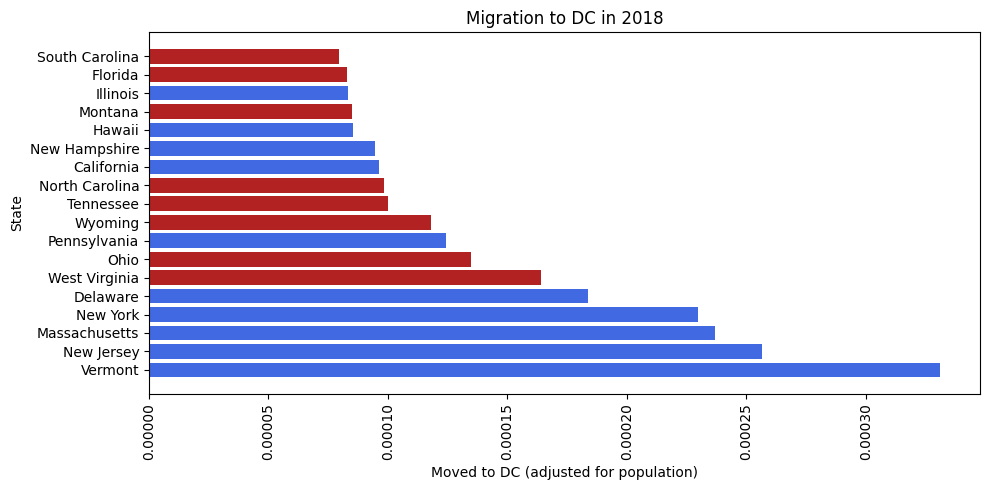

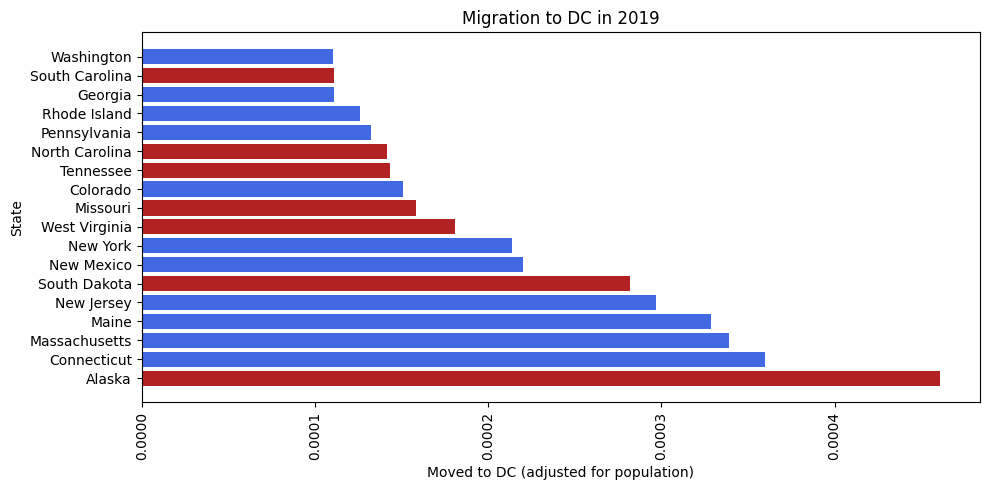

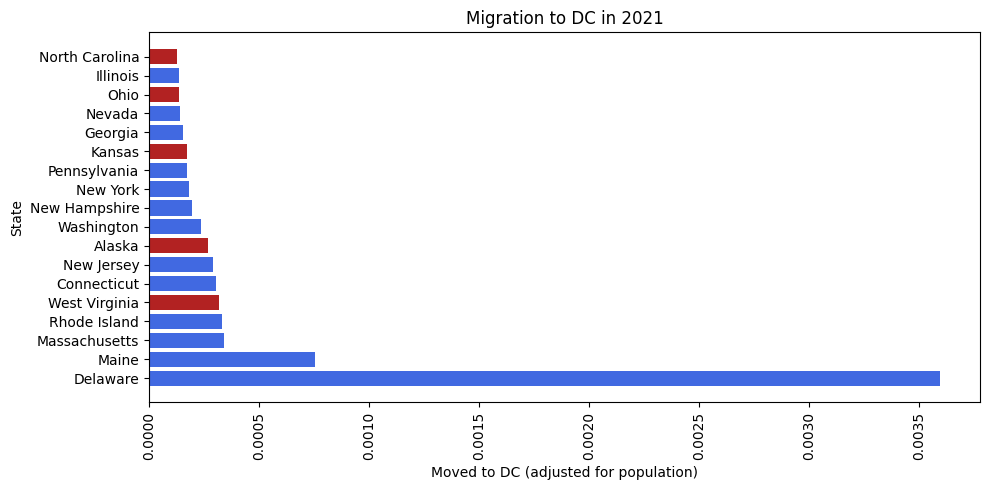

In [26]:
import matplotlib.pyplot as plt

for df in dfs:

    # Keep only the 8 states with the largest migration values
    df = df.nlargest(18, "migrated_adjusted")
    df.reset_index(drop=True, inplace=True)

    party_colors = {
    "REPUBLICAN": "firebrick",
    "DEMOCRAT": "royalblue"
    }

    colors = [party_colors.get(party, "gray") for party in df["winning_party"]]

    plt.figure(figsize=(10, 5))

    plt.barh(
        df["state"],                   # Labels on the x-axis
        df["migrated_adjusted"],       # Height of each bar
        # xerr=df["moe_adjusted"],       # Error bars (+/-)
        # capsize=3                      # Small horizontal caps on error bars
        color=colors

    )

    # Add labels and a title
    plt.title(f'Migration to DC in {df.loc[0, 'year']}')
    plt.xlabel("Moved to DC (adjusted for population)")
    plt.ylabel("State")

    plt.xticks(rotation=90) # Rotate state names so they don't overlap

    plt.tight_layout()  # Automatically adjust spacing

    plt.show() # Display the chart


Saving top 20 and top 15 and top 10 for each of the election years so I can refer back

In [27]:
top_dfs = {}

top_15_dfs = []

for df in dfs:
    year = df["year"].iloc[0]  # Get the year from the first row

    # top_dfs[f"{year}_top10"] = df.nlargest(10, "migrated_adjusted").reset_index(drop=True)
    # top_dfs[f"{year}_top15"] = df.nlargest(15, "migrated_adjusted").reset_index(drop=True)
    # top_dfs[f"{year}_top20"] = df.nlargest(20, "migrated_adjusted").reset_index(drop=True)

    top_15_dfs.append(df.nlargest(15, "migrated_adjusted").reset_index(drop=True))

# top_dfs["2021_top20"] #testing

Going to try some maps! Want to make contrasting 2021 and 2017 maps

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px

from PIL import Image
from matplotlib.patches import Patch, Circle

Load US states geometries

In [29]:
# states = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip")

Merge data and geometry

In [30]:
# merged = states.merge(top_dfs["2021_top20"], left_on="NAME", right_on="state", how="left")

Plot

In [31]:
# fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# merged.plot(
#     column="migrated_adjusted",          # or any numeric/boolean column
#     cmap="coolwarm",         # color scheme
#     linewidth=0.8,
#     edgecolor="black",
#     legend=True,
#     ax=ax
# )

# ax.set_title("Migration to DC in 2021")
# ax.axis("off")

# plt.show()

Trying plotly instead of the above:



cleaned_for_plotly:

Make  a new column that adjusts the sign of winner_percent_of_votes so I can map with colors both corresponding to each party, but also how red or blue (how high the percent that voted for that presidential candidate.

If DEMOCRAT  -> keep value positive
If REPUBLICAN -> make value negative

In [32]:
for i in range(len(top_15_dfs)):
    top_15_dfs[i]["percent_won_and_party"] = np.where(
        top_15_dfs[i]["winning_party"] == "DEMOCRAT",
        top_15_dfs[i]["winner_percent_of_votes"],    # keep as-is (positive)
        -top_15_dfs[i]["winner_percent_of_votes"]     # flip sign to negative
    )

Plotly also requires 2 letter codes for states, so need to fix that

In [33]:
us_state_abbrev = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC"
}

for i in range(len(top_15_dfs)):
    top_15_dfs[i]["state_code"] = top_15_dfs[i]["state"].map(us_state_abbrev)

Map for 2016

remember that dfs = [df_2005, df_2009, df_2013, df_2015, df_2016, df_2017, df_2018, df_2019, df_2021]

In [34]:

fig_2016 = px.choropleth(
    top_15_dfs[4],
    locations="state_code",
    locationmode="USA-states",
    color="percent_won_and_party", 
    scope="usa",
    color_continuous_scale=["#AA0000", '#C88FE4',"#0645B4"],
    range_color=[-0.8, 0.8]
)

fig_2016.show()

Map for 2017:

In [35]:

fig_2017 = px.choropleth(
    top_15_dfs[5],
    locations="state_code",
    locationmode="USA-states",
    color="percent_won_and_party",
    scope="usa",
    color_continuous_scale=["#AA0000", '#C88FE4',"#0645B4"],
    range_color=[-0.8, 0.8]
)

fig_2017.show()



Map for 2018

In [36]:
fig_2018 = px.choropleth(
    top_15_dfs[6],
    locations="state_code",
    locationmode="USA-states",
    color="percent_won_and_party",
    scope="usa",
    color_continuous_scale=["#AA0000", '#C88FE4',"#0645B4"],
    range_color=[-0.8, 0.8]
)

fig_2018.show()

Map for 2019

In [37]:
fig_2019 = px.choropleth(
    top_15_dfs[7],
    locations="state_code",
    locationmode="USA-states",
    color="percent_won_and_party",
    scope="usa",
    color_continuous_scale=["#AA0000", '#C88FE4',"#0645B4"],
    range_color=[-0.8, 0.8]
)

fig_2019.show()

Map for 2021

In [38]:
top_15_dfs[8].head()


,state,pop_migrated,MOE +/-,state_population,migrated_adjusted,moe_adjusted,winning_party,winner_percent_of_votes,year,percent_won_and_party,state_code
0,Delaware,3560,1052,989948,0.003596,0.001063,DEMOCRAT,0.587430,2021,0.587430,DE
1,Maine,1028,573,1362359,0.000755,0.000421,DEMOCRAT,0.525256,2021,0.525256,ME
2,Massachusetts,2389,870,7029917,0.000340,0.000124,DEMOCRAT,0.651230,2021,0.651230,MA
3,Rhode Island,366,348,1097379,0.000334,0.000317,DEMOCRAT,0.594762,2021,0.594762,RI
4,West Virginia,568,437,1793716,0.000317,0.000244,REPUBLICAN,0.686316,2021,-0.686316,WV


In [39]:
fig_2021 = px.choropleth(
    top_15_dfs[8],
    locations="state_code",
    locationmode="USA-states",
    color="percent_won_and_party",
    scope="usa",
    color_continuous_scale=["#AA0000", '#C88FE4',"#0645B4"],
    range_color=[-0.8, 0.8]
)

fig_2021.show()



In [40]:
top_15_dfs[8]

,state,pop_migrated,MOE +/-,state_population,migrated_adjusted,moe_adjusted,winning_party,winner_percent_of_votes,year,percent_won_and_party,state_code
0,Delaware,3560,1052,989948,0.003596,0.001063,DEMOCRAT,0.587430,2021,0.587430,DE
1,Maine,1028,573,1362359,0.000755,0.000421,DEMOCRAT,0.525256,2021,0.525256,ME
2,Massachusetts,2389,870,7029917,0.000340,0.000124,DEMOCRAT,0.651230,2021,0.651230,MA
3,Rhode Island,366,348,1097379,0.000334,0.000317,DEMOCRAT,0.594762,2021,0.594762,RI
4,West Virginia,568,437,1793716,0.000317,0.000244,REPUBLICAN,0.686316,2021,-0.686316,WV
5,Connecticut,1102,562,3605944,0.000306,0.000156,DEMOCRAT,0.592607,2021,0.592607,CT
6,New Jersey,2709,1162,9288994,0.000292,0.000125,DEMOCRAT,0.573342,2021,0.573342,NJ
7,Alaska,196,179,733391,0.000267,0.000244,REPUBLICAN,0.528331,2021,-0.528331,AK
8,Washington,1817,849,7705281,0.000236,0.000110,DEMOCRAT,0.579703,2021,0.579703,WA
9,New Hampshire,266,329,1377529,0.000193,0.000239,DEMOCRAT,0.527078,2021,0.527078,NH


In [41]:
top_15_dfs[4].head(10)


,state,pop_migrated,MOE +/-,state_population,migrated_adjusted,moe_adjusted,year,winning_party,winner_percent_of_votes,percent_won_and_party,state_code
0,Connecticut,1225,594,3605944,0.000340,0.000165,2016,DEMOCRAT,0.545663,0.545663,CT
1,Delaware,278,287,989948,0.000281,0.000290,2016,DEMOCRAT,0.533533,0.533533,DE
2,Massachusetts,1974,731,7029917,0.000281,0.000104,2016,DEMOCRAT,0.590501,0.590501,MA
3,Rhode Island,268,224,1097379,0.000244,0.000204,2016,DEMOCRAT,0.544066,0.544066,RI
4,New York,4762,1210,20201249,0.000236,0.000060,2016,DEMOCRAT,0.561361,0.561361,NY
5,Pennsylvania,2468,848,13002700,0.000190,0.000065,2016,REPUBLICAN,0.485779,-0.485779,PA
6,Illinois,2418,990,12812508,0.000189,0.000077,2016,DEMOCRAT,0.558254,0.558254,IL
7,West Virginia,296,337,1793716,0.000165,0.000188,2016,REPUBLICAN,0.686306,-0.686306,WV
8,New Jersey,1494,756,9288994,0.000161,0.000081,2016,DEMOCRAT,0.554531,0.554531,NJ
9,Indiana,957,826,6785528,0.000141,0.000122,2016,REPUBLICAN,0.569400,-0.569400,IN


In [42]:
fig_2009 = px.choropleth(
    top_15_dfs[1],
    locations="state_code",
    locationmode="USA-states",
    color="percent_won_and_party",
    scope="usa",
    color_continuous_scale=["#AA0000", '#C88FE4',"#0645B4"],
    range_color=[-0.8, 0.8]
)

fig_2009.show()

Contrasting with non election years

In [43]:
fig_2009 = px.choropleth(
    top_15_dfs[1],
    locations="state_code",
    locationmode="USA-states",
    color="percent_won_and_party",
    scope="usa",
    color_continuous_scale=["#AA0000", '#C88FE4',"#0645B4"],
    range_color=[-0.8, 0.8]
)

fig_2009.show()

Save them as .svgs

In [44]:
# 4. Export the map to a vector SVG file


fig_2009.write_image("2009_map.svg", engine="kaleido")
fig_2016.write_image("2016_map.svg", engine="kaleido")
fig_2017.write_image("2017_map.svg", engine="kaleido")
fig_2019.write_image("2019_map.svg", engine="kaleido")
fig_2021.write_image("2021_map.svg", engine="kaleido")

print("Map successfully exported as 'choropleth_map.subplots.svg'!")

/var/folders/4t/dlz7f1jn6gl_h8g2l5076hj80000gn/T/ipykernel_29017/842350676.py:4: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_2009.write_image("2009_map.svg", engine="kaleido")
/var/folders/4t/dlz7f1jn6gl_h8g2l5076hj80000gn/T/ipykernel_29017/842350676.py:5: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_2016.write_image("2016_map.svg", engine="kaleido")
/var/folders/4t/dlz7f1jn6gl_h8g2l5076hj80000gn/T/ipykernel_29017/842350676.py:6: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_2017.write_image("2017_map.svg", engine="kaleido")
/var/folders/4t/dlz7f1jn6gl_h8g2l5076hj80000gn/T/ipykernel_29017/842350676.py:7: D

Map successfully exported as 'choropleth_map.subplots.svg'!


Generating top 15 lists!

In [45]:
with open("top15.txt", "w") as f:
    for i in range(len(top_15_dfs)):
        print(top_15_dfs[i]['year'][0], file=f)
        states = []
        for state in top_15_dfs[i]['state']:
            states.append(state)
        print(*states, sep="\n", file=f)
        print("---", file=f)